# PRM FTE & Fleet Optimisation Model: S25 Baseline to S26 Forecast
### Scenarios:
1. **Current:** 
2. **Relay 1:1:** Ambulift fo Minibus (single flight)
3. **Relay Optimised:** Ambulift to Minibus (Multi-Stand Pooling)

**Objective:** Minimise Cost (Capex and Opex) while maintaining <1% ECAC SLA Failure 

In [ ]:
import sys
from pathlib import Path


# Go up until repo root
repo_root = Path.cwd().parent
sys.path.append(str(repo_root))


import simpy
import pandas as pd
import numpy as np
import random
from tabulate import tabulate

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import export_text
from scipy import stats

from modules.utils.query import query
from modules.utils.dates import add_date_parts, to_datetime
from modules.config import JETBRIDGE_STANDS
from modules.domain.prm.minibus import passenger_level_flags
from modules.domain.prm.efficiency import average_wait_time, average_arrival_time, arrival_time_statistics, wait_time_statistics

#Formatting for plots
sns.set_theme(style="whitegrid")

In [30]:
#user
USER = "jamie_douglas"

#configurable variables
NO_JETBRIDGE_AIRLINES = ["2S", "3V", "6I", "8H", "AP", "BE", "BGH", "BT", "BY", "C3", "D0", "D8", "DS", "DY", "E4", "E9", "EA", "EC", "ED", "EJU", "EVE", "EW", "FH", "FHY", "FI", "FR", "FX", "GR", "HAT", "HV", "LM", "NPT", "OS", "QS", "RC", "RK", "SK", "SRR", "T3", "TO", "TP", "U2", "V3", "W6", "WF", "WK", "XC", "XQ", "ZT", "LO" ]

#Probability Constants
WCHS_OWN_CHAIR_PROB = 0.109

#SSR numeric mapping
def map_ssr(ssr_code):
    if ssr_code == "WCHC": return 3
    if ssr_code == "WCHS": return 2
    return 1 #all others (WCHR, DNPA etc)
    

#historical comparison dates
#Summer 2025
START_S25 = "2025-03-30"
END_S25   = "2025-10-26"



## Phase 1: Data Ingestion and Assumptions
In this section, we load the S25 Actuals and define the Stochastic variables (the probability distributions) derived from historical data

In [31]:
#Load Data Functions

def load_prm_data(start: str, end: str) -> pd.DataFrame:
    """ 
    Load PRM Data where Billing PRM = 1, for time period 
    
    Parameters
    ----------
    start: str
        Start of window (ISO format)
    end: str
        End of window (ISO format)
    
     Returns
    ----------
    pd.DataFrame
        Dataframe of PRM Data with columns:
        ['Job ID', 'Passenger ID', 'Operation Date', 'Vehicle Type', 'Operation Date_day', 'Operation Date_month', 'Operation Date_year']
    """

    
    start_op = start.replace("-", "")   # "2025-01-01" → "20250101"
    end_op   = end.replace("-", "")     # "2026-01-01" → "20260101"


    df = query(
        table="PRM.CompletedServicesByJob",
        columns = [
            "RequestID AS [Job ID]",
            "PassengerID AS [Passenger ID]",
            "FlightID AS [Flight ID]",
            "AirlineCode_IATA AS [Airline Code]",
            "FlightNumber AS [Flight Number]",
            "Sector",
            "ArrDep AS [A/D]",
            "adhocOrPlanned AS [Adhoc Or Planned]",
            "requestCreated_DAteTime_Local AS [Request Created DT]",
            "currentSSRCode AS [SSR Code]",
            "startService_DateTime_Local AS [Job Start Time]",
            "finishService_DateTime_Local AS [Job End Time]",
            "disregardCode AS [Disregard Code]",
            "scheduledPickupLocation AS [Scheduled PU Location]",
            "scheduledDestinationLocation AS [Scheduled DO Location]",
            "actualPickupLocation AS [Actual PU Location]",
            "actualDestinationLocation AS [Actual DO Location]",
            "scheduledPickup_DateTime_Local AS [Scheduled PU DT]",
            "arriveAtLocation_DateTime_Local AS [Location Arrival DT]",
            "arrival_ActualGate_DateTime_Local AS [Plane Gate Arrival DT]",
            "ScheduledDateTime_Local AS [Scheduled Flight DT]",
            "ActualDateTime_Local AS [Actual Flight DT]",
            "EmployeeName AS [Employee]",
            "VehicleShortName AS [Vehicle Model]",
            "VehicleTypeName AS [Vehicle Type]",
            "StandCode AS [Stand]"
        ],
        where = ["BillingPRM = 1",
                 "Operation_DateID_Local >= :start_op",
                 "Operation_DateID_Local < :end_op",
        ],
        params= {"start_op": start_op, "end_op": end_op},
        query_option = "OPTION (RECOMPILE)",
    )
    
    df = to_datetime(df, ["Request Created DT", "Job Start Time", "Job End Time", "Scheduled PU DT", "Location Arrival DT", "Plane Gate Arrival DT", "Scheduled Flight DT", "Actual Flight DT"])
    df = add_date_parts(df, col="Actual Flight DT", day=True)

    df["Flight Number"] = df["Flight Number"].astype(str).str.lstrip("0")
    df["Vehicle Type"] = df["Vehicle Type"].fillna("No Vehicle")

    return df

def load_flight_data(start: str, end: str) -> pd.DataFrame:
    """
    Load flight data from EAL.FlightPerformance for merge.
    """

    df = query(
        table="EAL.FlightPerformance",
        columns=[
            "FlightID AS [Flight ID]",
            "ScheduledDateTime_Local AS [Scheduled Flight DT]",
            "ArrDeptureCode AS [A/D]",
            "FlightNumber AS [Flight Number]",
            "AirlineCode_IATA AS [Airline Code]",
            "Sector",
            "StandCode AS [Stand]",
            "DepartureGate AS [Departure Gate]",
            "ActualDateTime_Local AS [Actual Flight DT]",
            "ChocksDateTime_Local AS [Chocks DT]",
            "BoardingStartDateTime_Local AS [Boarding Start Time]",
            "BoardingEndDateTime_Local AS [Boarding End Time]",
            "TurnAroundFlightNumber AS [Turnaround Flight Number]",
            "TurnAroundStandCode AS [Turnaround Stand Code]",
            "TurnAround_ScheduledDateTime_Local AS [Turnaround Scheduled DT]",
            "TurnAround_Actual_Local AS [Turnaround Actual DT]",
            "Turnaround_Chocks_LOcal AS [Turnaround Chocks]",
            "MinutesOnStand_Chocks AS [Minutes on Chocks]",
            "RemoteStand AS [Remote Stand]",
            "IsPassengerFlight"
        ],
        where=[
            "ScheduledDateTime_Local >= :start",
            "ScheduledDateTime_Local < :end",
        ],
        params={"start": start, "end": end},
        query_option="OPTION (RECOMPILE)",
    )

    df = to_datetime(df, ["Scheduled Flight DT", "Actual Flight DT", "Chocks DT", "Boarding Start Time", "Boarding End Time", "Turnaround Scheduled DT", "Turnaround Actual DT", "Turnaround Chocks"])
    df = add_date_parts(df, col="Actual Flight DT", day=True)

    df["Flight Number"] = df["Flight Number"].astype(str).str.lstrip("0")

    return df


In [32]:
#Load Flight Data
df_flights = load_flight_data(START_S25, END_S25)

df_flights = df_flights.sort_values("Chocks DT").reset_index(drop=True)

#2. Effective Remote Flag
df_flights["IsEffectiveRemote"] = np.where(
    (df_flights["Remote Stand"] ==1) |
    (df_flights["Airline Code"].isin(NO_JETBRIDGE_AIRLINES)),
    1, 0
)

def calculate_rolling_stress(row , df):
    #Create a +- 30 minute window
    start_window = row["Chocks DT"] - timedelta(minutes=30)
    end_window = row["Chocks DT"] + timedelta(minutes=30)

    #Count all flights that fall inside specific box
    concurrent_count = len(df[(df["Chocks DT"] >= start_window) &
                            (df["Chocks DT"] <= end_window)])
    
    #subtract 1 so flight itself isnt counted
    return concurrent_count - 1

df_flights['Concurrent Stress'] = df_flights.apply(lambda x: calculate_rolling_stress(x, df_flights), axis=1)



In [33]:
#Load PRM Data
df_prm = load_prm_data(START_S25, END_S25)

df_prm["SSR numeric"] = df_prm["SSR Code"].apply(map_ssr)

#Assign passenger flags to prm_df
df_prm_flags = passenger_level_flags(df_prm)

np.random.seed(42)
rolls = np.random.rand(len(df_prm_flags))

#Add has own chair column
df_prm_flags["Has Own Chair"] = 0
df_prm_flags.loc[df_prm_flags["SSR numeric"] ==3, "Has Own Chair"] = 1
df_prm_flags.loc[(df_prm_flags["SSR numeric"] ==2) & (rolls < WCHS_OWN_CHAIR_PROB), "Has Own Chair"] = 1

#Condition column
#If arrival we want to know where they STARTED
#If departure we want to know where they ended

df_prm_flags['Strategic Location'] = np.where(
    df_prm_flags["Sector"] == "A",
    df_prm_flags["Actual PU Location"],
    df_prm_flags["Actual DO Location"]
)

agg_rules = {
    "Sector": 'first',
    "A/D": 'first',
    "Day": 'first',
    "Adhoc Or Planned": 'first',
    "SSR Code": 'first',
    "SSR numeric": 'first',
    "Has Own Chair": 'max',
    "Job Start Time": 'min',
    "Job End Time": 'max',
    "Strategic Location": 'first',
    "Location Arrival DT": 'min',
    "Plane Gate Arrival DT": 'first',
    "Scheduled Flight DT": 'first',
    "Stand": 'first',
    "PassengerType" : 'first'
}

df_prm_grouped = df_prm_flags.groupby(["Passenger ID", "Airline Code", "Flight Number"]).agg(agg_rules).reset_index()

#Calculate PRMs per flight
flight_prm_count = df_prm_flags.groupby(["Flight Number", "Airline Code", "Day"])['Passenger ID'].nunique().reset_index(name="PRM Flight Count")

df_flights = pd.merge(df_flights, flight_prm_count, on=["Flight Number", "Airline Code", "Day"], how="left").fillna({'PRM Flight Count':0})

#merge with flight data
df_prm_master = pd.merge(
    df_prm_grouped, 
    df_flights[
        ["Flight Number", "Airline Code", "Day", "IsEffectiveRemote", "Concurrent Stress", "Minutes on Chocks", "PRM Flight Count"]
    ],
    on = ["Flight Number", "Airline Code", "Day"],
    how = "left"
)

#check for PRMs that didn't find flight
orphans = df_prm_master['IsEffectiveRemote'].isna().sum()
print(f"Waring: {orphans} passengers could not be matched to a flight")

print(df_prm_master["PRM Flight Count"].value_counts())

Waring: 4962 passengers could not be matched to a flight
PRM Flight Count
2.0     21542
3.0     18441
1.0     17664
4.0     14216
5.0     10590
6.0      8220
7.0      5866
8.0      4528
9.0      3375
10.0     2710
11.0     1727
12.0     1452
13.0     1001
14.0      882
15.0      570
0.0       479
16.0      416
17.0      374
19.0      228
18.0      162
20.0      140
23.0      115
22.0       88
21.0       84
30.0       60
Name: count, dtype: int64


In [34]:
#Prepare Turnaround Lookup

#split the table into A/D buckets
arrivals = df_flights[df_flights['A/D'] == "A"][["Flight Number", "Airline Code", 'Turnaround Flight Number', 'PRM Flight Count', 'Scheduled Flight DT']]
departures = df_flights[df_flights['A/D'] == "D"][["Flight Number", "Airline Code", 'Turnaround Flight Number', 'PRM Flight Count', 'Scheduled Flight DT']]

#match A to D using the Turnaround Number
turnaround_bridge = pd.merge(
    arrivals,
    departures,
    left_on = ["Turnaround Flight Number", "Airline Code"],
    right_on = ["Flight Number", "Airline Code"],
    how = 'inner',
    suffixes = ('_ARR', '_DEP'  )
)

#Time filter: Ensure departure is within 0.5 to 4 hours of arrival
turnaround_bridge['Gap'] = (turnaround_bridge["Scheduled Flight DT_DEP"] - turnaround_bridge["Scheduled Flight DT_ARR"]).dt.total_seconds() / 3600
turnaround_bridge = turnaround_bridge[(turnaround_bridge['Gap'] > 0.5) & (turnaround_bridge['Gap'] < 4)]

#Create the final look up
lookup_A = turnaround_bridge[["Flight Number_ARR", "Scheduled Flight DT_ARR", "Airline Code", "PRM Flight Count_ARR"]].rename(columns={"Flight Number_ARR": "Flight Number", "Scheduled Flight DT_ARR": "Scheduled Flight DT", "PRM Flight Count_ARR": "Turnaround PRM Count"})
lookup_D = turnaround_bridge[["Flight Number_DEP", "Scheduled Flight DT_DEP", "Airline Code", "PRM Flight Count_DEP"]].rename(columns={"Flight Number_DEP": "Flight Number", "Scheduled Flight DT_DEP": "Scheduled Flight DT", "PRM Flight Count_DEP": "Turnaround PRM Count"})

turnaround_lookup = pd.concat([lookup_A, lookup_D])

#Collapse Passenger Data
df_prm_master = pd.merge(
    df_prm_master,
    turnaround_lookup, 
    on=['Flight Number', 'Airline Code', 'Scheduled Flight DT'],
    how = 'left'
).fillna({'Turnaround PRM Count': 0})

### Operational Asset Allocation Analysis: S25 Baseline

This analysis extracts historical dispatch logic from Summer 2025 (S25) data to understand the allocation of Ambulifts and Minibuses

Objective:
- Identify Dispatch Rules
- Baseline for Scenarios
- FTE Impact

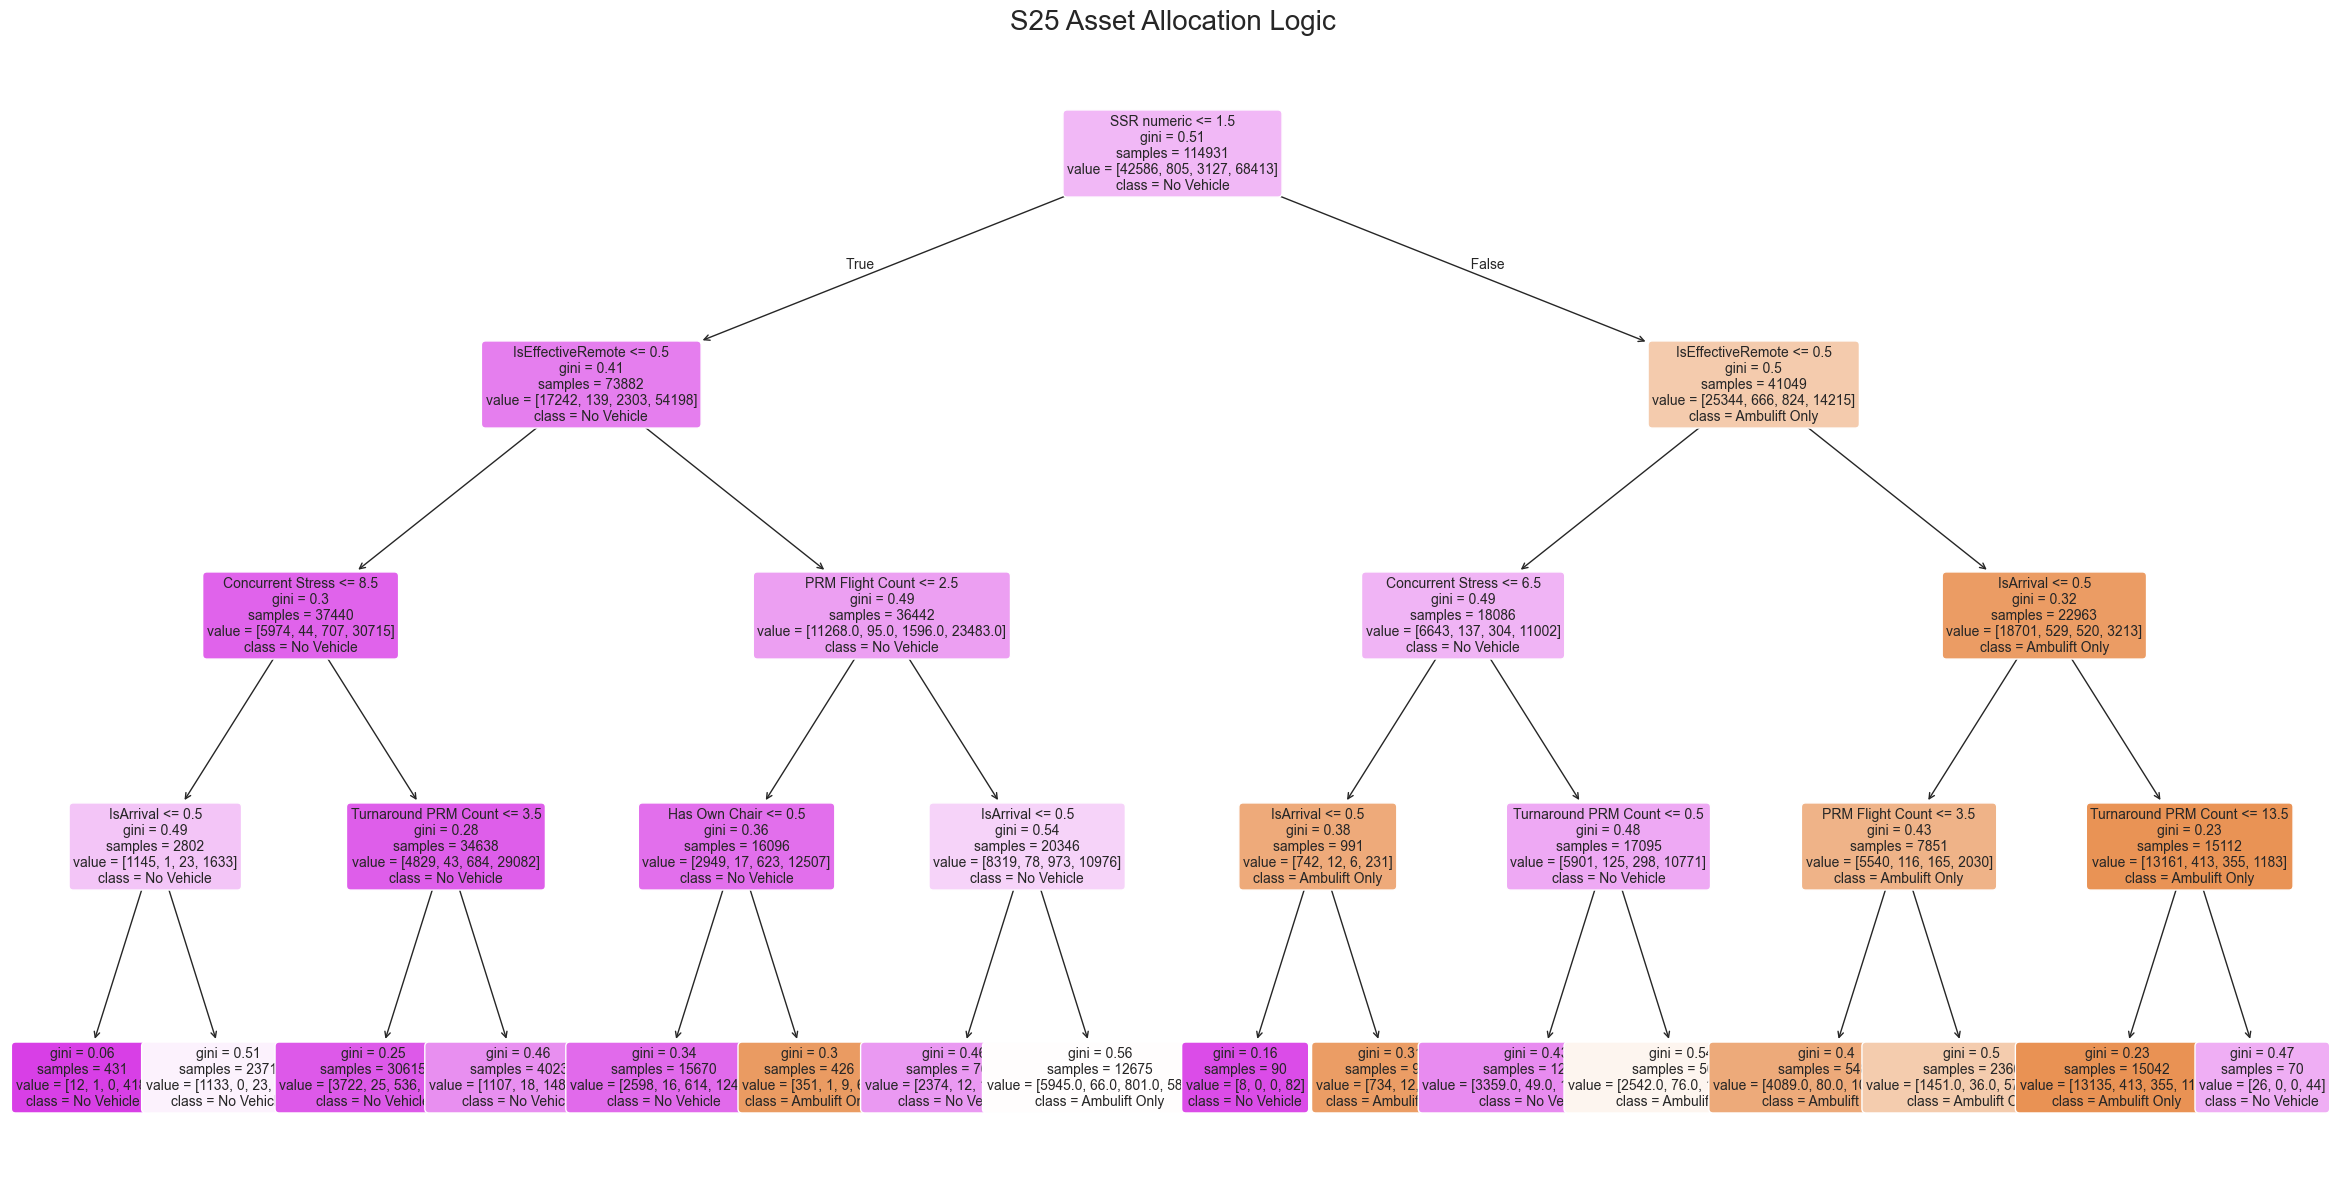

|--- SSR numeric <= 1.50
|   |--- IsEffectiveRemote <= 0.50
|   |   |--- Concurrent Stress <= 8.50
|   |   |   |--- IsArrival <= 0.50
|   |   |   |   |--- class: No Vehicle
|   |   |   |--- IsArrival >  0.50
|   |   |   |   |--- class: No Vehicle
|   |   |--- Concurrent Stress >  8.50
|   |   |   |--- Turnaround PRM Count <= 3.50
|   |   |   |   |--- class: No Vehicle
|   |   |   |--- Turnaround PRM Count >  3.50
|   |   |   |   |--- class: No Vehicle
|   |--- IsEffectiveRemote >  0.50
|   |   |--- PRM Flight Count <= 2.50
|   |   |   |--- Has Own Chair <= 0.50
|   |   |   |   |--- class: No Vehicle
|   |   |   |--- Has Own Chair >  0.50
|   |   |   |   |--- class: Ambulift Only
|   |   |--- PRM Flight Count >  2.50
|   |   |   |--- IsArrival <= 0.50
|   |   |   |   |--- class: No Vehicle
|   |   |   |--- IsArrival >  0.50
|   |   |   |   |--- class: Ambulift Only
|--- SSR numeric >  1.50
|   |--- IsEffectiveRemote <= 0.50
|   |   |--- Concurrent Stress <= 6.50
|   |   |   |--- IsArriv

In [35]:
#Create numeric flags for decision tree to understand text columns
df_prm_master["IsArrival"] = np.where(df_prm_master["A/D"] == "A", 1, 0)
df_prm_master["IsAdhoc"] = np.where(df_prm_master["Adhoc Or Planned"] == "Ad-Hoc", 1, 0)

#Define the final feature list
features = [
    'SSR numeric', 
    'Has Own Chair',
    'PRM Flight Count',
    'Turnaround PRM Count',
    'Concurrent Stress',
    'IsEffectiveRemote',
    'IsArrival',
    'IsAdhoc'
]

#Drop rows that are missing the Target (PassengerType) or any features ensuring the model doesnt have to guess from incomplete data
df_tree_ready = df_prm_master.dropna(subset=["PassengerType"] + features)

#X = The Inputs (The situation)
#y = The Output (the deicison made in S25)
X = df_tree_ready[features]
y = df_tree_ready["PassengerType"]

#max depth = 4 so tree is readable, min_samples_leaf = 50 to prevent overfitting
clf = tree.DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
clf.fit(X, y)

#visualise the rule book
plt.figure(figsize=(30,15))
tree.plot_tree(clf, feature_names=features, class_names=[str(c) for c in clf.classes_], filled=True, rounded=True, fontsize=10, precision=2)
plt.title("S25 Asset Allocation Logic", fontsize=20)
plt.show()

#Print the rules in text format
tree_rules = export_text(clf, feature_names=features)
print(tree_rules)



next steps:

travel times:
- stand to curb matrix
- time to repositition from one jobs drop off to the next pick up
- waiting time
- 10th/50th/90th percentile for docking loading and lowering (can we get this)
- how long on average is an ambulift attached to a spin flight?
- how many minutes before chocks on must the vehicle be present to guarantee 100% SLA
- percentage of PRMs that exit at the arrivals halls (and time with pusher from doors to drop off) versus just the doors
- staff break windows
- hard code the passenger limit for each vehicle model

Demand and profile assumptions
- SSR code mix %
- penetration rates by country and airline
- no show rate
- ad-hoc demand rate
- companion ratio

Other:
- stand probability, likelihood of a flight being assigned a remote vs a jetbridge stand
- a stress coefficient applied to service time during peak windows
- average walking speed of agents who push

Variance and reliability:
- think about actual vs scheduled times
- equipment downtime
- 

5YP assumptions from Feb 25 (TO REVIEW)
 -agent productivity (1.1 Arr, 1.0 Dep)
 - driver productivity - 3
 - % PRMs ambulift
 -penetration rates (and increase )
 -East terminus reception centre (penetration rate, 60%, capacity = 16, waiting time = 18min, companion/PRM = 1)
 - Airside REception Centre (Penetration rate = 26%, capacity = 26, waiting time = 70 min, companion/PRM = 1)
 PENETRATION RATE: in 5YP 2026, peneratation rate assumptions script (5YP) 
 ?Lead Time time the PRM starts service

### Assumption Gathering
To gather assumptions to place into Scenario 0, 1 and 2 models

##### Penetration rate


In [36]:
#Per Flight assumptions
 
forecasting_penrate_byCountry = pd.read_csv(r"C:\Users\{}\Edinburgh Airport Limited\Shared Files - Business Planning\5YP\2026\5. PRM\Assumptions\input files\forecasting_penrate_byCountry.csv".format(USER))

# Ensure 'Country' is a column, not an index
forecasting_penrate_byCountry_reset = forecasting_penrate_byCountry.copy()
# Now 'Country' is a string column, and the rest are years
value_vars = [col for col in forecasting_penrate_byCountry_reset.columns if col != 'Country']
# Melt to long format
forecasting_penrate_long = forecasting_penrate_byCountry_reset.melt(
    id_vars='Country',
    value_vars=value_vars,
    var_name='Year',
    value_name='PenetrationRate'
 )

forecasting_penrate_long['Year'] = forecasting_penrate_long['Year'].astype(int)

print(forecasting_penrate_long.head())


    Country  Year PenetrationRate
0   ALBANIA  2027           0.60%
1   AUSTRIA  2027           0.60%
2   BELGIUM  2027           0.50%
3  BULGARIA  2027           1.70%
4    CANADA  2027           1.60%


##### Lead Time

In [37]:
LeadTime = pd.read_csv(r"C:\Users\{}\Edinburgh Airport Limited\Shared Files - Business Planning\5YP\2026\5. PRM\Assumptions\input files\LeadTime.csv".format(USER))

LeadTime = LeadTime.rename(columns={'Country Name': 'Country'})

print(tabulate(LeadTime.head(), headers='keys', tablefmt='psql', showindex=False))

+-----------+------------+
| Country   |   LeadTime |
|-----------+------------|
| ALBANIA   |      85.31 |
| AUSTRIA   |      68.34 |
| BELGIUM   |      77.28 |
| BULGARIA  |      72.46 |
| CANADA    |      89.15 |
+-----------+------------+


##### Average Wait time


In [38]:
avgbv, avgbvpt = average_wait_time(df_prm_flags)

print(f" Average Wait Time by Vehicle Type: \n {avgbv}")
print(f" Average Wait Time by Passenger Type x Vehicle Type: \n {avgbvpt}")

 Average Wait Time by Vehicle Type: 
   Vehicle Type  Average Wait Time (minutes)
0     Ambulift                     5.315219
1     Mini Bus                     6.374467
2   No Vehicle                     6.325285
 Average Wait Time by Passenger Type x Vehicle Type: 
   Vehicle Type  PassengerType  Average Wait Time (minutes)
0     Ambulift  Ambulift Only                     5.346436
1     Ambulift           Both                     3.723561
2     Mini Bus           Both                     2.889832
3     Mini Bus  Mini Bus Only                     7.146105
4   No Vehicle  Ambulift Only                     2.125803
5   No Vehicle           Both                     2.255733
6   No Vehicle  Mini Bus Only                     1.910153
7   No Vehicle     No Vehicle                     7.295953


In [ ]:
wait_stats_by_vehicle, wait_stats_by_vehicle_and_passengertype = wait_time_statistics(df_prm_flags)

print(f" Average Wait Time by Vehicle Type: \n {wait_stats_by_vehicle}")
print(f" Average Wait Time by Passenger Type x Vehicle Type: \n {wait_stats_by_vehicle_and_passengertype}")

In [39]:
from modules.analytics.grouping import group_average

prm_arrival = df_prm_flags.copy()
flight_chocks = df_flights.copy()

prm_flight_chocks = prm_arrival.merge(flight_chocks, on=["Airline Code", "Flight Number", "Day"], how="left")

prm_flight_chocks["Arrival Time before plane"] = (prm_flight_chocks["Chocks DT"] - prm_flight_chocks["Location Arrival DT"]).dt.total_seconds() / 60

#Average Arrival time per vehicle type
avg_AT_by_vehicle = group_average(prm_flight_chocks, by_cols=["Vehicle Type"], value_col="Arrival Time before plane", out_col="Average Arrival Time (minutes)")

#Average Arrival time by Vehicle Type x Passenger Type
avg_AT_by_vehicle_and_passengertype = group_average(prm_flight_chocks, by_cols=["Vehicle Type", "PassengerType"], value_col="Arrival Time before plane", out_col="Average Arrival Time (minutes)")

print(avg_AT_by_vehicle)
print(avg_AT_by_vehicle_and_passengertype)

  Vehicle Type  Average Arrival Time (minutes)
0     Ambulift                        8.606779
1     Mini Bus                       -3.252266
2   No Vehicle                       46.083053
  Vehicle Type  PassengerType  Average Arrival Time (minutes)
0     Ambulift  Ambulift Only                        9.065459
1     Ambulift           Both                      -14.893129
2     Mini Bus           Both                      -20.748409
3     Mini Bus  Mini Bus Only                        0.900601
4   No Vehicle  Ambulift Only                       51.416812
5   No Vehicle           Both                       42.705666
6   No Vehicle  Mini Bus Only                       41.673749
7   No Vehicle     No Vehicle                       45.022860


In [40]:
avg_AT_by_vehicle, avg_AT_by_vehicle_and_passengertype = average_arrival_time(df_prm_flags, df_flights)

print(avg_AT_by_vehicle)
print(avg_AT_by_vehicle_and_passengertype)

  Vehicle Type  Average Arrival Time before chocks on (minutes)
0     Ambulift                                         5.315219
1     Mini Bus                                         6.374467
2   No Vehicle                                         6.325285
  Vehicle Type  PassengerType  Average Arrival Time before chocks on (minutes)
0     Ambulift  Ambulift Only                                         5.346436
1     Ambulift           Both                                         3.723561
2     Mini Bus           Both                                         2.889832
3     Mini Bus  Mini Bus Only                                         7.146105
4   No Vehicle  Ambulift Only                                         2.125803
5   No Vehicle           Both                                         2.255733
6   No Vehicle  Mini Bus Only                                         1.910153
7   No Vehicle     No Vehicle                                         7.295953


In [ ]:
arrival_stats_bv, arrival_stats_bvpt = arrival_time_statistics(df_prm_flags, df_flights)

print(arrival_stats_bv)
print(arrival_stats_bvpt)